In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
data=pd.read_csv(r"C:\Users\Ravi\OneDrive\Desktop\Mock test 5.0\Crop Prediction.csv")

In [33]:
data.head()

,Record_ID,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_per_Area,Rainfall_Category,Fertilizer_per_Area,Pesticide_per_Area,Yield_Category,Year_Group
0,1,Arecanut,1997,Whole Year,Assam,73814,56708.0,2051,7024878.38,22882.34,0.796087,0.768255,High,95.17,0.31,Low,1997-2000
1,2,Arhar/Tur,1997,Kharif,Assam,6637,4685.0,2051,631643.29,2057.47,0.710435,0.705891,High,95.17,0.31,Low,1997-2000
2,3,Castor seed,1997,Kharif,Assam,9378,22.0,2051,75755.32,246.76,0.238333,0.027638,High,95.17,0.31,Low,1997-2000
3,4,Coconut,1997,Whole Year,Assam,19656,126905000.0,2051,1870661.52,6093.36,0.982466,6456.298331,High,95.17,0.31,Very High,1997-2000
4,5,Cotton(lint),1997,Kharif,Assam,1739,794.0,2051,165500.63,539.09,0.420909,0.456584,High,95.17,0.31,Low,1997-2000


In [34]:
data.isnull().sum()

Record_ID              0
Crop                   0
Crop_Year              0
Season                 0
State                  0
Area                   0
Production             0
Annual_Rainfall        0
Fertilizer             0
Pesticide              0
Yield                  0
Production_per_Area    0
Rainfall_Category      0
Fertilizer_per_Area    0
Pesticide_per_Area     0
Yield_Category         0
Year_Group             0
dtype: int64

In [35]:
y = data["Yield_Category"]
X = data.drop("Yield_Category", axis=1)

In [36]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (19689, 16)
Shape of y: (19689,)


In [37]:
from sklearn.preprocessing import StandardScaler

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64","float64"]).columns

print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))

Categorical Columns: ['Crop', 'Season', 'State', 'Rainfall_Category', 'Year_Group']
Numerical Columns: ['Record_ID', 'Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Production_per_Area', 'Fertilizer_per_Area', 'Pesticide_per_Area']


In [38]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [39]:
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Final Processed Data:")
print(X_encoded.head())

Final Processed Data:
   Record_ID  Crop_Year      Area  Production  Annual_Rainfall  Fertilizer  \
0  -1.731963  -1.866375 -0.133297   -0.060002         0.757649   -0.208577   
1  -1.731787  -1.866375 -0.226782   -0.060206         0.757649   -0.224177   
2  -1.731611  -1.866375 -0.222968   -0.060225         0.757649   -0.225533   
3  -1.731435  -1.866375 -0.208664    0.438350         0.757649   -0.221154   
4  -1.731259  -1.866375 -0.233598   -0.060222         0.757649   -0.225314   

   Pesticide     Yield  Production_per_Area  Fertilizer_per_Area  ...  \
0  -0.121745 -0.083798            -0.090640            -1.602681  ...   
1  -0.219385 -0.083903            -0.090708            -1.602681  ...   
2  -0.227875 -0.084485            -0.091446            -1.602681  ...   
3  -0.200462 -0.083568             6.931092            -1.602681  ...   
4  -0.226504 -0.084260            -0.090979            -1.602681  ...   

   State_Uttar Pradesh  State_Uttarakhand  State_West Bengal  \
0     

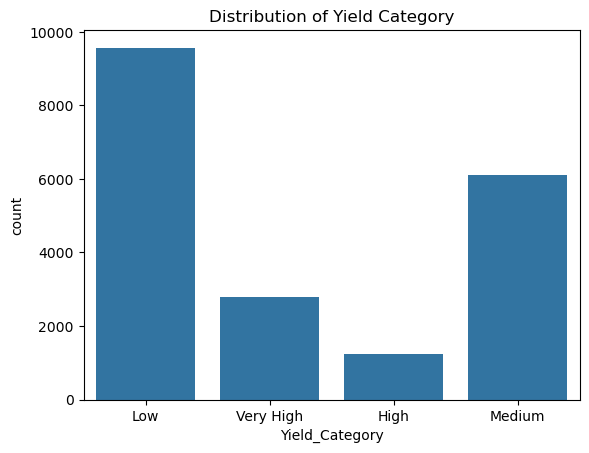

In [40]:
sns.countplot(x="Yield_Category",data=data)
plt.title("Distribution of Yield Category")
plt.show()

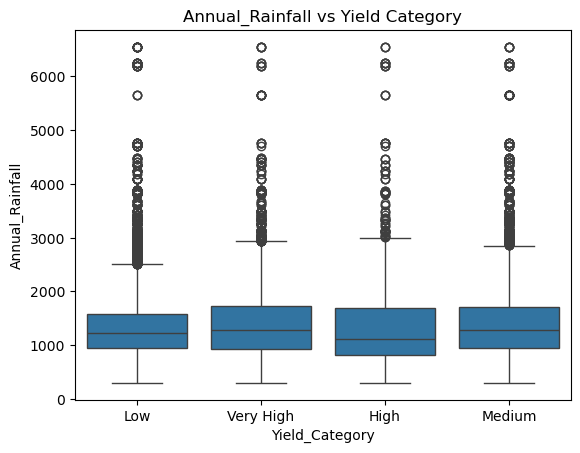

In [41]:
sns.boxplot(x="Yield_Category", y="Annual_Rainfall", data=data)
plt.title("Annual_Rainfall vs Yield Category")
plt.show()

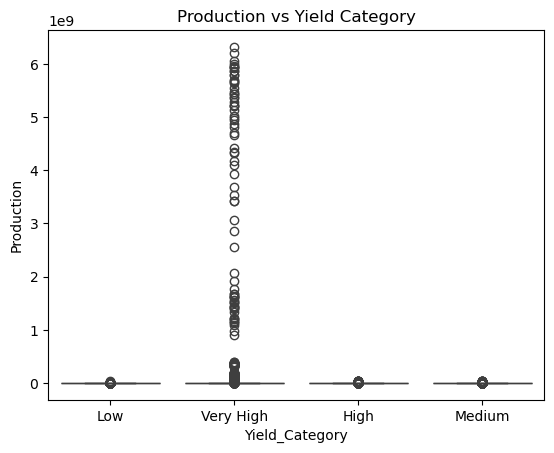

In [42]:
sns.boxplot(x="Yield_Category", y="Production", data=data)
plt.title("Production vs Yield Category")
plt.show()

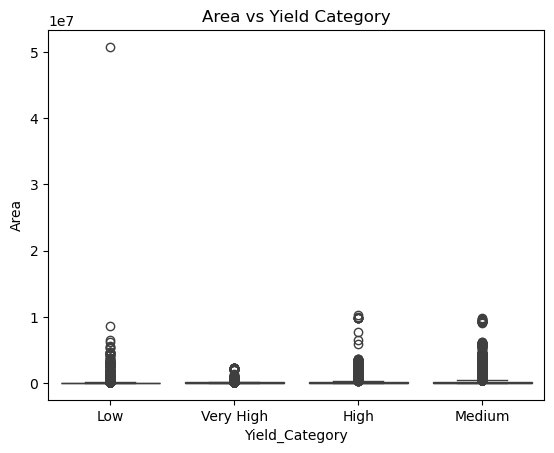

In [43]:
sns.boxplot(x="Yield_Category", y="Area", data=data)
plt.title("Area vs Yield Category")
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42)

In [46]:
error_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(1 - accuracy_score(y_test, pred_k))

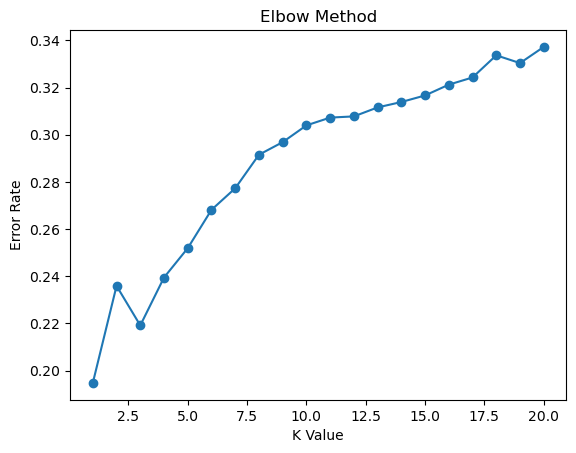

In [47]:
plt.plot(range(1, 21), error_rate, marker='o')
plt.title("Elbow Method")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

In [48]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [51]:
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7480954799390553
Confusion Matrix:n [[ 120   53   50   19]
 [  18 1690  181   27]
 [  40  384  789   19]
 [  35   97   69  347]]
Classification Report:n               precision    recall  f1-score   support

        High       0.56      0.50      0.53       242
         Low       0.76      0.88      0.82      1916
      Medium       0.72      0.64      0.68      1232
   Very High       0.84      0.63      0.72       548

    accuracy                           0.75      3938
   macro avg       0.72      0.66      0.69      3938
weighted avg       0.75      0.75      0.74      3938



In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [53]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9870492635855764
Confusion Matrix:
 [[ 217    0   20    5]
 [   1 1900   15    0]
 [   1    3 1227    1]
 [   4    0    1  543]]
Classification Report:
               precision    recall  f1-score   support

        High       0.97      0.90      0.93       242
         Low       1.00      0.99      1.00      1916
      Medium       0.97      1.00      0.98      1232
   Very High       0.99      0.99      0.99       548

    accuracy                           0.99      3938
   macro avg       0.98      0.97      0.98      3938
weighted avg       0.99      0.99      0.99      3938

